# Importing Library

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

## Load dataset

In [2]:
wine = load_wine()

X = wine.data
y = wine.target

feature_name = wine.feature_names

df = pd.DataFrame(X, columns= feature_name)

df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [3]:
df.shape

(178, 13)

#### As I can  tell, PCA is required Scaler to be performed

In [4]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [5]:
pca = PCA(n_components=2) # 

X_pca = pca.fit_transform(X_scaled)

#### Visualize PCA

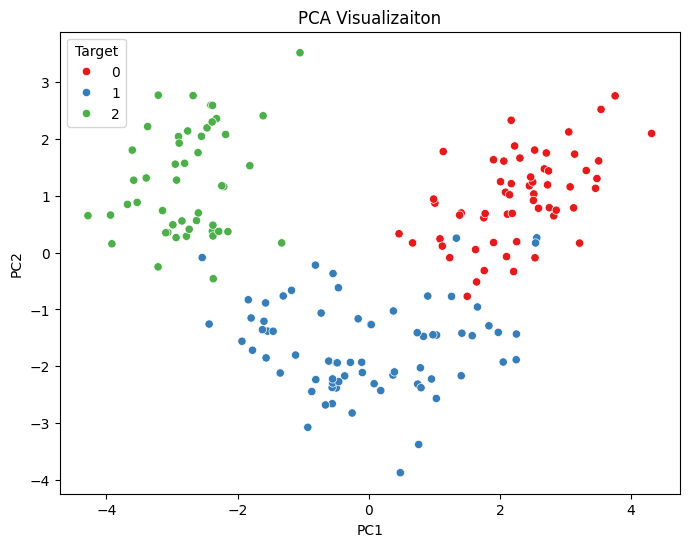

In [6]:
pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:,1],
    "Target" : y
})

plt.figure(figsize= (8, 6))


sns.scatterplot(
    data = pca_df,
    x = "PC1",
    y= "PC2",
    hue = "Target",
    palette="Set1"
)

plt.title("PCA Visualizaiton")
plt.show()



In [7]:
pca.explained_variance_ratio_

array([0.36198848, 0.1920749 ])

In [8]:
sum(pca.explained_variance_ratio_)

np.float64(0.5540633835693526)

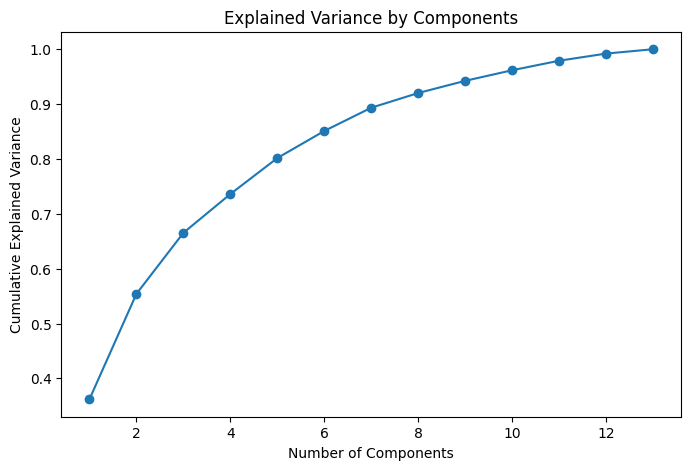

In [9]:
pca_full = PCA()

pca_full.fit(X_scaled)

cumulative_variance = np.cumsum(
    pca_full.explained_variance_ratio_
)

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(cumulative_variance)+1),
    cumulative_variance,
    marker='o'
)

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance by Components")

plt.show()

This figure from above helps to decide how many components we should keep. For instance, with 95% of variance, we will need 8 components


Reason for using PCA:
PCA reduces dimentionality while preserving most variance. It helps to reduce noise,
improve visualization, reduc overfitting, and sometimes improve computational efficiency.

#### t-SNE

In [10]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42
)

X_tsne = tsne.fit_transform(X_scaled)

c:\Users\nguye\miniconda3\envs\testenv\lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\nguye\miniconda3\envs\testenv\lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "c:\Users\nguye\miniconda3\envs\testenv\lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
  File "c:\Users\nguye\miniconda3\envs\testenv\lib\subprocess.py", line 503, in run
    with Popen(*popenargs, **kwargs) as process:
  File "c:\Users\nguye\miniconda3\envs\testenv\lib\subprocess.py", line 971, in __ini

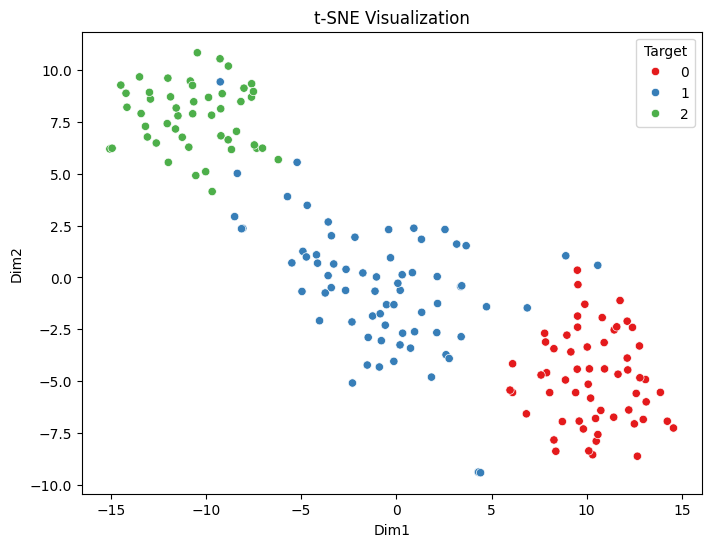

In [11]:
tsne_df = pd.DataFrame({
    "Dim1": X_tsne[:, 0],
    "Dim2": X_tsne[:, 1],
    "Target": y
})

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=tsne_df,
    x="Dim1",
    y="Dim2",
    hue="Target",
    palette="Set1"
)

plt.title("t-SNE Visualization")
plt.show()

“PCA is better for dimensionality reduction and feature compression, while t-SNE is mainly used for visualizing complex high-dimensional data.”

### KMeans on PCA data

In [12]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42
) 

clusters = kmeans.fit_predict(X_pca)

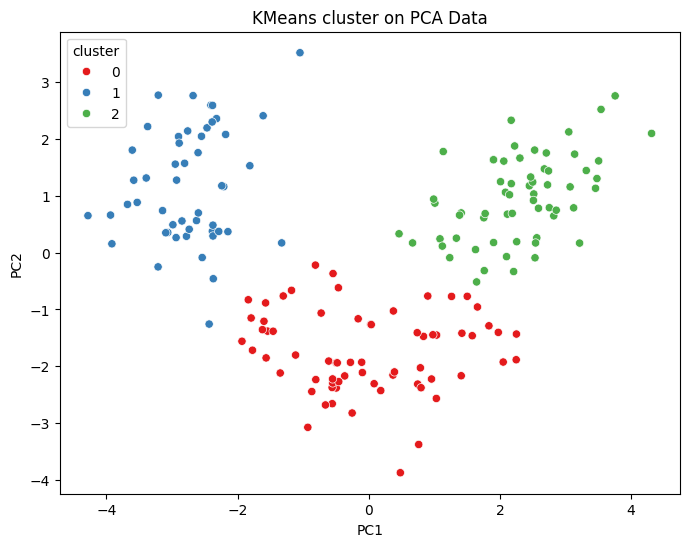

In [14]:
clusters_df = pd.DataFrame({
    "PC1": X_pca[:,0],
    "PC2": X_pca[:,1],
    "cluster": clusters}
)

plt.figure(figsize= (8, 6))

sns.scatterplot(
    data = clusters_df,
    x="PC1",
    y="PC2",
    hue= "cluster",
    palette="Set1"
)

plt.title("KMeans cluster on PCA Data")
plt.show()

In [15]:
score = silhouette_score(X_pca, clusters)

print(score)

0.5601697480957202
